# Transfer Function — worked examples

The companion notebook to the [Transfer Function
manual](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/transfer-function.md). Same three examples, same
demo files, same numbers — computed here in a few lines of
`spwb.processing` instead of clicked in the application.

The manual carries the explanations and the history; this notebook is where
you change a parameter and watch what happens. Nothing here imports Qt, so
it runs anywhere `pip install spwb[io]` runs.

### Three ways to use this, needing progressively more

1. **Read it.** GitHub renders this file with every graph and number
   already in place. Nothing to install, nothing to run.
2. **Run it as a script** — no Jupyter involved at all:
   `python examples/manuals/transfer_function.py`
3. **Run it cell by cell** in VS Code or Jupyter: change the resolution,
   the window, the estimator, and watch the answer move.

For (3), VS Code will ask which kernel to use. **Choose the Python
interpreter you installed SPWB into** — the same one `pip install -e .`
was run with. There is no separate "spwb" environment unless you created
one yourself. If it is not offered, run `pip install ipykernel` into it
and reopen the notebook.

| Section | Demo file | Shows |
|---|---|---|
| 1 | `09_TF_SDOF_resonance_H1.h5` | A known resonance, the phase crossing, bias error |
| 2 | `10_TF_Coherence_partial.h5` | Coherence finding what the input did not cause |
| 3 | `11_TF_H1_vs_H2_input_noise.h5` | H1 vs H2 and the coherence identity |

Every section ends with an `assert` on the numbers the manual quotes.

## Setup

The demo datasets are generated rather than committed — they are 21 MB, and
`spwb.demo` reproduces them exactly from a fixed seed. The cell below
creates them if they are missing, so there is nothing to download. The
application offers the same thing under **File > Create Demo Data ...**.

In [1]:
from pathlib import Path

import numpy as np

try:                                    # notebook: draw figures inline
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:                       # plain script: draw to a buffer
    import warnings

    import matplotlib
    matplotlib.use("Agg")
    # plt.show() is a no-op under Agg and says so once per figure; the
    # figures are still built, and the notebook build uses the inline
    # backend where they are captured.
    warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
import matplotlib.pyplot as plt


def demo_folder() -> Path:
    """Where the demonstration datasets live.

    A git checkout keeps them in its own untracked ``.data/``. Anyone who
    installed the wheel has no checkout and gets them beside wherever they
    are working instead. Either way ``spwb.demo`` writes them on demand.
    """
    here = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
    for folder in (here, *here.parents):
        if (folder / "pyproject.toml").is_file() and (folder / "src").is_dir():
            return folder / ".data"
    return Path.cwd() / "spwb-demo-data"


DATA = demo_folder()

if not any(DATA.glob("[0-9][0-9]_*.h5")):
    from spwb.demo import write_demo_data

    print(f"creating the demonstration datasets in {DATA} ...")
    write_demo_data(DATA)

print(f"datasets : {len(list(DATA.glob('*.h5')))} files in {DATA}")

datasets : 14 files in <your pySPWB checkout>\.data


In [2]:
from spwb.processing.dsp import transfer_function
from spwb.processing.dsp.transfer import format_transfer_function
from spwb.processing.io import read_hdf5

#: the true system behind demo files 09-11
FN, ZETA = 80.0, 0.05
Q = 1 / (2 * ZETA)
DAMPED_PEAK = FN * np.sqrt(1 - 2 * ZETA ** 2)


def load(filename: str) -> dict:
    """Every signal in a demo file, keyed by name.

    Keyed rather than indexed on purpose: ``read_hdf5`` returns signals in
    the file's own alphabetical order, not the order they were written.
    """
    return {s.name: s for s in read_hdf5(DATA / filename)}


def measure(reference, response, *, df=1.0, overlap=0.5, window="bh_7term",
            estimator="H1"):
    """One transfer function, returned as (freqs, complex H, coherence)."""
    tf, coherence = transfer_function(
        reference, response, freq_resolution=df, overlap=overlap,
        window=window, estimator=estimator)
    return tf, np.asarray(tf.attributes["TF_Complex"]), coherence


print(f"the system under test: fn = {FN:g} Hz, zeta = {ZETA:g}, "
      f"Q = {Q:g}, damped peak at {DAMPED_PEAK:.3f} Hz")

the system under test: fn = 80 Hz, zeta = 0.05, Q = 10, damped peak at 79.800 Hz


## 1. A resonance you already know the answer to

**File:** `09_TF_SDOF_resonance_H1.h5` — white noise through a
single-degree-of-freedom resonance at 80 Hz with 5 % damping, 20 s at
8192 Hz.

Manual: [Worked example
1](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/transfer-function.md#worked-example-1--a-resonance-you-already-know-the-answer-to).

In [3]:
sdof = load("09_TF_SDOF_resonance_H1.h5")
tf, H, coherence = measure(sdof["Input (reference)"], sdof["Output (response)"])
mag = np.abs(H)
peak = int(np.argmax(mag))

print(f"  {tf.name!r}   unit {tf.y_unit!r}   "
      f"{tf.attributes['FFT_Nb_Averages']} averages")
print(f"  DC gain |H(0)|      : {mag[0]:.5f}   "
      "<- a mass-spring-damper passes DC straight through")
print(f"  magnitude peaks at  : {peak * tf.dt:g} Hz, value {mag[peak]:.5f}")
print(f"  theory says         : {DAMPED_PEAK:.3f} Hz, value ~ Q = {Q:g}")
print(f"  phase at {FN:g} Hz       : {np.degrees(np.angle(H[80])):.3f} deg   "
      "<- the reliable reading")
print(f"  coherence at {FN:g} Hz   : {float(coherence.y[80]):.5f}   "
      "<- not contamination; see below")

  'Output (response) / Input (reference)'   unit 'm/N'   39 averages
  DC gain |H(0)|      : 1.00006   <- a mass-spring-damper passes DC straight through
  magnitude peaks at  : 79 Hz, value 9.24141
  theory says         : 79.800 Hz, value ~ Q = 10
  phase at 80 Hz       : -89.897 deg   <- the reliable reading
  coherence at 80 Hz   : 0.94379   <- not contamination; see below


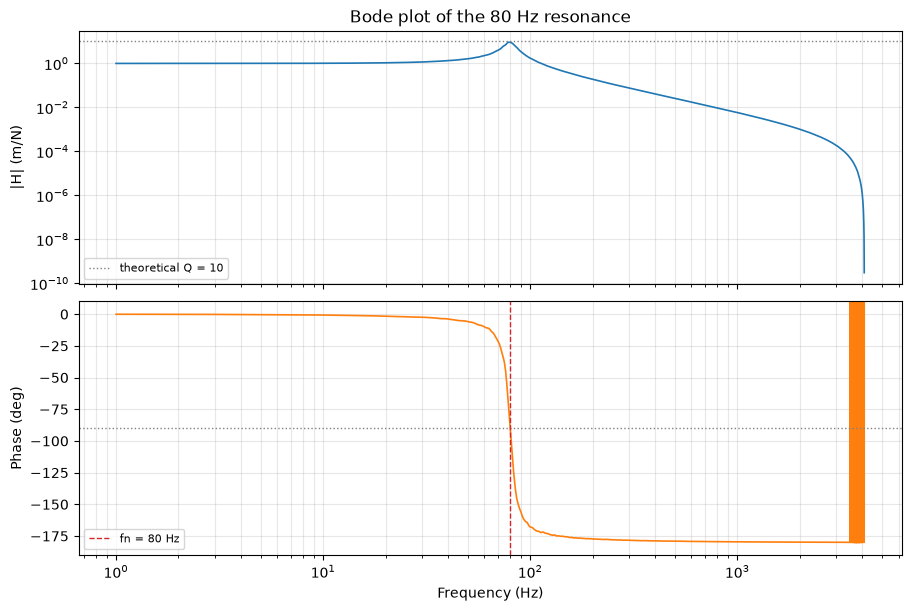

In [4]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                                  constrained_layout=True)
top.loglog(tf.t[1:], mag[1:], lw=1.2)
top.set(ylabel=f"|H| ({tf.y_unit})", title="Bode plot of the 80 Hz resonance")
top.axhline(Q, color="grey", ls=":", lw=1, label=f"theoretical Q = {Q:g}")
top.legend(fontsize=8)

phase = format_transfer_function(tf, "Phase (Degree)", coherence)
bottom.semilogx(phase.t[1:], phase.y[1:], lw=1.2, color="tab:orange")
bottom.axhline(-90, color="grey", ls=":", lw=1)
bottom.axvline(FN, color="tab:red", ls="--", lw=1, label=f"fn = {FN:g} Hz")
bottom.set(xlabel="Frequency (Hz)", ylabel="Phase (deg)", ylim=(-190, 10))
bottom.legend(fontsize=8)
for ax in (top, bottom):
    ax.grid(True, which="both", alpha=0.3)
plt.show()

### The coherence dip is bias error, not contamination

Nothing is polluting this measurement — the output was computed from the
input and nothing else. Inside one bin at the resonance the response
changes steeply, and the estimator reports that as lost linearity. Coarsen
the resolution and it gets worse, taking the peak with it.

In [5]:
print(f"  {'df (Hz)':>8} {'averages':>9} {'peak |H|':>9} {'peak at':>9} "
      f"{'coherence at peak':>18}")
sweep = {}
for df in (0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0):
    tfd, Hd, cohd = measure(sdof["Input (reference)"], sdof["Output (response)"],
                            df=df)
    md = np.abs(Hd)
    pk = int(np.argmax(md))
    sweep[df] = (md[pk], pk * tfd.dt, float(cohd.y[pk]))
    print(f"  {df:8g} {tfd.attributes['FFT_Nb_Averages']:9d} {md[pk]:9.4f} "
          f"{pk * tfd.dt:8.3f}  {float(cohd.y[pk]):18.4f}")

print(f"\n  at df = 0.125 Hz the measurement recovers Q = {sweep[0.125][0]:.2f} "
      f"(true {Q:g}) and a peak\n  at {sweep[0.125][1]:.3f} Hz (true "
      f"{DAMPED_PEAK:.2f}). At df = 8 Hz the same data reports "
      f"Q = {sweep[8.0][0]:.1f} -\n  a resonance less than half as sharp as "
      "the real one, and nothing in the\n  magnitude curve looks wrong. Only "
      "the coherence tells you.")

   df (Hz)  averages  peak |H|   peak at  coherence at peak
     0.125         4   10.1260   79.875              0.9994
      0.25         9   10.0387   80.500              0.9967
       0.5        19    9.9646   80.000              0.9882
         1        39    9.2414   79.000              0.9474
         2        79    7.8609   80.000              0.8180
         4       159    6.0131   80.000              0.6053
         8       319    4.1675   80.000              0.3942

  at df = 0.125 Hz the measurement recovers Q = 10.13 (true 10) and a peak
  at 79.875 Hz (true 79.80). At df = 8 Hz the same data reports Q = 4.2 -
  a resonance less than half as sharp as the real one, and nothing in the
  magnitude curve looks wrong. Only the coherence tells you.


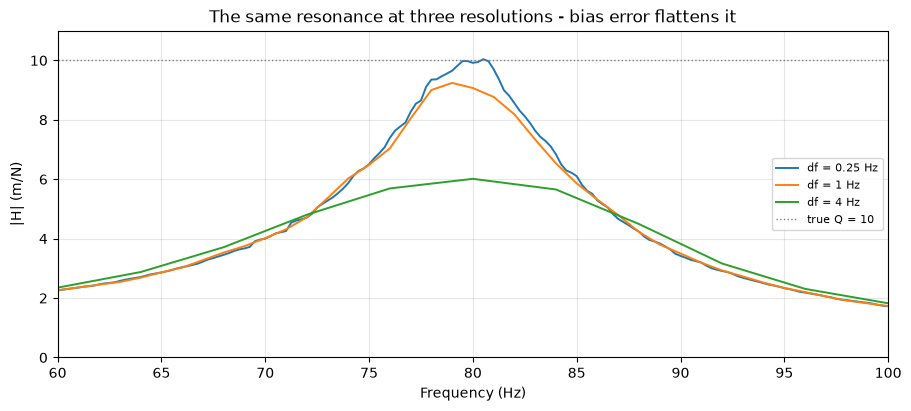

In [6]:
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for df in (0.25, 1.0, 4.0):
    tfd, Hd, _ = measure(sdof["Input (reference)"], sdof["Output (response)"], df=df)
    ax.plot(tfd.t, np.abs(Hd), lw=1.4, label=f"df = {df:g} Hz")
ax.axhline(Q, color="grey", ls=":", lw=1, label=f"true Q = {Q:g}")
ax.set(xlim=(60, 100), ylim=(0, 11), xlabel="Frequency (Hz)",
       ylabel=f"|H| ({tf.y_unit})",
       title="The same resonance at three resolutions - bias error flattens it")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()

**And the window matters too.** A transfer function divides one spectrum
by another, so leakage in either corrupts both. That is why this window
defaults to a 7-term Blackman-Harris rather than the FFT window's Hanning.

In [7]:
print(f"  {'window':14} {'peak |H|':>9} {'median coherence 20-1000 Hz':>29}")
for win in ("bh_7term", "hanning", "rectangular"):
    tfw, Hw, cohw = measure(sdof["Input (reference)"], sdof["Output (response)"],
                            window=win)
    band = (tfw.t > 20) & (tfw.t < 1000)
    print(f"  {win:14} {np.abs(Hw).max():9.4f} "
          f"{float(np.median(cohw.y[band])):29.5f}")

  window          peak |H|   median coherence 20-1000 Hz
  bh_7term          9.2414                       0.99998
  hanning           9.7001                       0.99999
  rectangular       9.8876                       0.54237


In [8]:
assert abs(mag[0] - 1.0) < 0.01, mag[0]
assert peak * tf.dt == 79.0
assert abs(np.degrees(np.angle(H[80])) + 90.0) < 0.2
assert abs(float(coherence.y[80]) - 0.9438) < 0.001
assert abs(sweep[0.125][0] - Q) < 0.2, "fine df must recover the true Q"
assert sweep[8.0][2] < 0.5, "coarse df must destroy the coherence"
print("section 1 OK - DC gain 1.000, phase -89.90 deg at 80 Hz, "
      f"Q recovered as {sweep[0.125][0]:.2f} at df = 0.125 Hz")

section 1 OK - DC gain 1.000, phase -89.90 deg at 80 Hz, Q recovered as 10.13 at df = 0.125 Hz


## 2. Coherence, or how much of this did the input cause

**File:** `10_TF_Coherence_partial.h5` — the same resonance, but the
response now carries interference between 300 and 500 Hz that the input
did not cause. A clean copy is included to compare against.

Manual: [Worked example
2](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/transfer-function.md#worked-example-2--coherence-or-how-much-of-this-did-the-input-cause).

In [9]:
partial = load("10_TF_Coherence_partial.h5")
reference = partial["Input (reference)"]
CONTAMINATED = "Output with 300-500 Hz interference"
CLEAN = "Output clean (for comparison)"

results = {}
for name in (CONTAMINATED, CLEAN):
    results[name] = measure(reference, partial[name], df=2.0)

print(f"  {'band':16} {'contaminated':>13} {'clean':>10}")
BANDS = {"320-480 Hz": (320, 480), "600-1500 Hz": (600, 1500),
         "60-100 Hz": (60, 100)}
for label, (lo, hi) in BANDS.items():
    values = []
    for name in (CONTAMINATED, CLEAN):
        tfc, _, cohc = results[name]
        mask = (cohc.t > lo) & (cohc.t < hi)
        values.append(float(cohc.y[mask].mean()))
    print(f"  {label:16} {values[0]:13.5f} {values[1]:10.5f}")
print("\n  the dip near 80 Hz is the SAME in both - that is the bias error "
      "from\n  section 1, present with or without interference. That is how "
      "you tell\n  the two kinds of coherence loss apart.")

  band              contaminated      clean
  320-480 Hz             0.01293    0.99987
  600-1500 Hz            0.99998    0.99998
  60-100 Hz              0.93455    0.93455

  the dip near 80 Hz is the SAME in both - that is the bias error from
  section 1, present with or without interference. That is how you tell
  the two kinds of coherence loss apart.


**Now the point of all this.** The magnitude alone gives no hint that the
300-500 Hz band is fictitious.

In [10]:
at_400 = {}
for name in (CONTAMINATED, CLEAN):
    tfc, Hc, _ = results[name]
    at_400[name] = float(np.abs(Hc)[int(round(400 / tfc.dt))])
    print(f"  |H| at 400 Hz, {name[:34]:36} {at_400[name]:.5f}")
print(f"\n  the contaminated measurement over-reads by a factor of "
      f"{at_400[CONTAMINATED] / at_400[CLEAN]:.0f}")

  |H| at 400 Hz, Output with 300-500 Hz interferenc   1.36958
  |H| at 400 Hz, Output clean (for comparison)        0.07056

  the contaminated measurement over-reads by a factor of 19


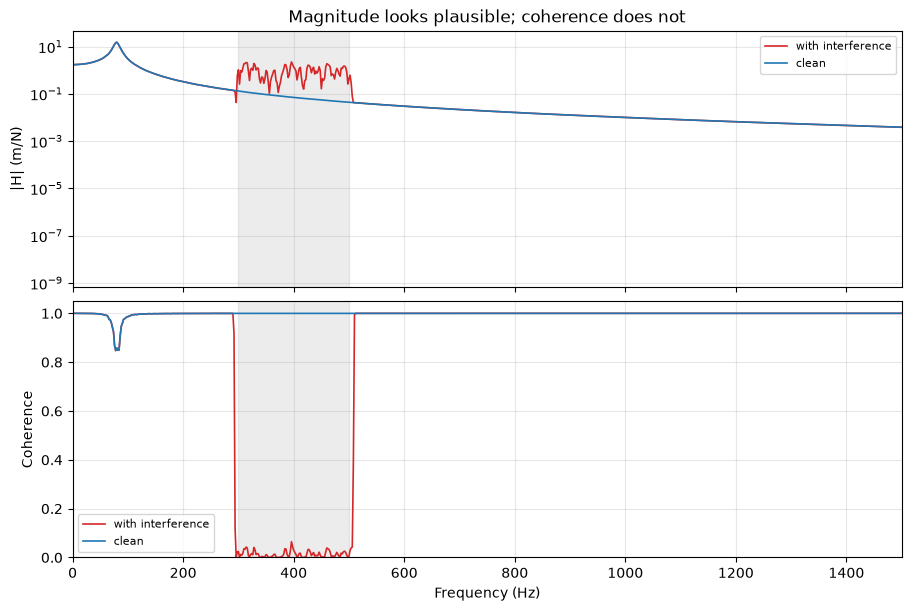

In [11]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                                  constrained_layout=True)
for name, colour in ((CONTAMINATED, "tab:red"), (CLEAN, "tab:blue")):
    tfc, Hc, cohc = results[name]
    label = "with interference" if name == CONTAMINATED else "clean"
    top.semilogy(tfc.t[1:], np.abs(Hc)[1:], lw=1.2, color=colour, label=label)
    bottom.plot(cohc.t[1:], cohc.y[1:], lw=1.2, color=colour, label=label)
top.set(ylabel="|H| (m/N)", title="Magnitude looks plausible; coherence does not")
bottom.set(xlabel="Frequency (Hz)", ylabel="Coherence", ylim=(0, 1.05),
           xlim=(0, 1500))
for ax in (top, bottom):
    ax.axvspan(300, 500, color="grey", alpha=0.15)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
plt.show()

In [12]:
_, _, coh_bad = results[CONTAMINATED]
_, _, coh_good = results[CLEAN]
inside = (coh_bad.t > 320) & (coh_bad.t < 480)
assert float(coh_bad.y[inside].mean()) < 0.1, "interference must destroy coherence"
assert float(coh_good.y[inside].mean()) > 0.99, "the clean output must not"
assert at_400[CONTAMINATED] / at_400[CLEAN] > 10
print(f"section 2 OK - coherence {float(coh_bad.y[inside].mean()):.4f} inside "
      f"the band against {float(coh_good.y[inside].mean()):.4f} clean, "
      f"magnitude over-read {at_400[CONTAMINATED] / at_400[CLEAN]:.0f}x")

section 2 OK - coherence 0.0129 inside the band against 0.9999 clean, magnitude over-read 19x


## 3. H1, H2, and where the noise is

**File:** `11_TF_H1_vs_H2_input_noise.h5` — the same resonance, but the
noise is on the **input**: the excitation is measured badly and the
response cleanly. This is the case H1 gets wrong.

Manual: [Worked example
3](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/transfer-function.md#worked-example-3--h1-h2-and-where-the-noise-is).

In [13]:
noisy = load("11_TF_H1_vs_H2_input_noise.h5")
ref11, resp11 = noisy["Input, noisy measurement"], noisy["Output, clean measurement"]

estimates = {}
print(f"  {'estimator':10} {'peak |H|':>9} {'peak at':>9} {'|H(0)|':>9} "
      f"{'|H| at 200 Hz':>14}")
for estimator in ("H1", "H3", "H2"):
    tfe, He, cohe = measure(ref11, resp11, estimator=estimator)
    me = np.abs(He)
    estimates[estimator] = (tfe, me, cohe)
    pk = int(np.argmax(me))
    print(f"  {estimator:10} {me[pk]:9.3f} {pk * tfe.dt:8.0f} Hz {me[0]:9.3f} "
          f"{me[200]:14.3f}")

  estimator   peak |H|   peak at    |H(0)|  |H| at 200 Hz
  H1            13.392       80 Hz     1.285          0.295
  H3            15.323       79 Hz     1.655          0.323
  H2            18.045       78 Hz     2.132          0.354


**H1 = γ² · H2, exactly.** Not a property of this dataset — an algebraic
identity, since H1 = Sxy/Sxx and H2 = Syy/Syx, whose ratio is
|Sxy|²/(Sxx·Syy), which *is* the coherence.

In [14]:
tf11, h1, coh11 = estimates["H1"]
_, h2, _ = estimates["H2"]
band = (tf11.t > 20) & (tf11.t < 1000)

print(f"  mean(H1 / H2)   in 20-1000 Hz : {float(np.mean(h1[band] / h2[band])):.5f}")
print(f"  mean(coherence) in 20-1000 Hz : {float(np.mean(coh11.y[band])):.5f}")
print("\n  So whenever coherence is below 1, H1 reads low by exactly that "
      "factor.\n  Which one is right depends on where the noise is:")
print("    noise on the RESPONSE  -> H1 is correct  (the usual case, hence "
      "the default)")
print("    noise on the REFERENCE -> H2 is correct  (this file)")
print("    noise on both          -> neither; H3 sits between them")

  mean(H1 / H2)   in 20-1000 Hz : 0.79575
  mean(coherence) in 20-1000 Hz : 0.79575

  So whenever coherence is below 1, H1 reads low by exactly that factor.
  Which one is right depends on where the noise is:
    noise on the RESPONSE  -> H1 is correct  (the usual case, hence the default)
    noise on the REFERENCE -> H2 is correct  (this file)
    noise on both          -> neither; H3 sits between them


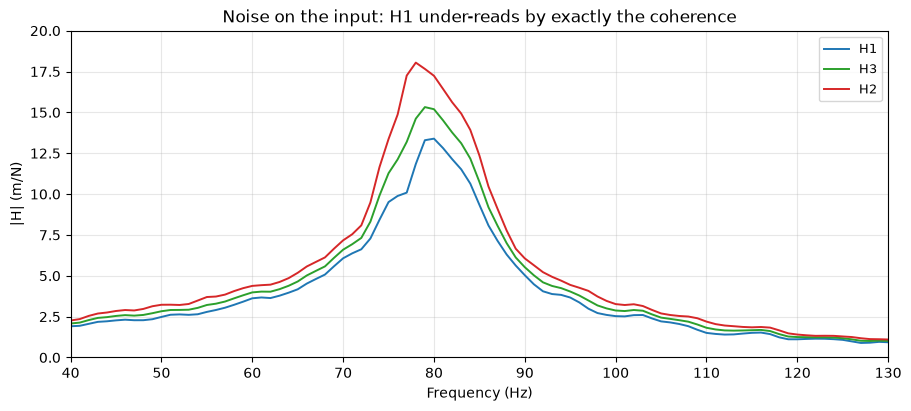

In [15]:
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for estimator, colour in (("H1", "tab:blue"), ("H3", "tab:green"),
                          ("H2", "tab:red")):
    tfe, me, _ = estimates[estimator]
    ax.plot(tfe.t, me, lw=1.4, color=colour, label=estimator)
ax.set(xlim=(40, 130), ylim=(0, 20), xlabel="Frequency (Hz)", ylabel="|H| (m/N)",
       title="Noise on the input: H1 under-reads by exactly the coherence")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.show()

**The clean case, for contrast.** On file 09 the estimators agree to six
digits everywhere the coherence is 1, and diverge in exactly one place —
the resonance — by exactly the coherence there.

In [16]:
_, h1_clean, coh_clean = (tf, np.abs(H), coherence)
_, h2_clean, _ = measure(sdof["Input (reference)"], sdof["Output (response)"],
                         estimator="H2")
h2_clean = np.abs(h2_clean)

print(f"  {'frequency':>10} {'H1':>11} {'H2':>11} {'ratio':>10} {'coherence':>11}")
for f in (10, 200, 1000, 79):
    note = "  <- the peak" if f == 79 else ""
    print(f"  {f:8d} Hz {h1_clean[f]:11.6f} {h2_clean[f]:11.6f} "
          f"{h1_clean[f] / h2_clean[f]:10.6f} {float(coh_clean.y[f]):11.6f}{note}")

   frequency          H1          H2      ratio   coherence
        10 Hz    1.015528    1.015537   0.999991    0.999991
       200 Hz    0.189379    0.189422   0.999774    0.999774
      1000 Hz    0.005815    0.005815   0.999994    0.999994
        79 Hz    9.241412    9.754377   0.947412    0.947412  <- the peak


In [17]:
ratio = float(np.mean(h1[band] / h2[band]))
gamma = float(np.mean(coh11.y[band]))
assert abs(ratio - gamma) < 1e-9, "H1/H2 must equal the coherence identically"
assert estimates["H2"][1].max() > estimates["H1"][1].max() > 0
assert abs(h1_clean[200] / h2_clean[200] - float(coh_clean.y[200])) < 1e-9
assert abs(h1_clean[79] / h2_clean[79] - float(coh_clean.y[79])) < 1e-9
print(f"section 3 OK - H1/H2 = {ratio:.5f} = mean coherence {gamma:.5f}, "
      "identically, on both files")

section 3 OK - H1/H2 = 0.79575 = mean coherence 0.79575, identically, on both files


## Where to go next

* The [Transfer Function manual](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/transfer-function.md) —
  the same three examples driven through the application, plus the history
  from Black's feedback amplifier to Bendat and Piersol's coherence.
* The [Time Processing](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/time-processing.md) and
  [FFT Analysis](https://github.com/Charette-AI-Group/pySPWB/blob/main/docs/manuals/fft-analysis.md) manuals, and their
  notebooks: [`time_processing.py`](https://github.com/Charette-AI-Group/pySPWB/blob/main/examples/manuals/time_processing.py),
  [`fft_analysis.py`](https://github.com/Charette-AI-Group/pySPWB/blob/main/examples/manuals/fft_analysis.py).
* `python tools/verify_demo_data.py` — the assertions that keep the demo
  datasets honest.

To use your own data, replace the `load(...)` calls with
`read_tdms("run.tdms")` or `read_hdf5("measurement.h5")`, and pick which
signal is the reference. Everything downstream is unchanged.

---

## Support This Work

If anything here was useful to you, please consider contributing.
SPWB is free and open source, and always will be — donations are
what let Charette AI Group keep maintaining it and open-sourcing
its other tools.

<p align="center">
  <a href="https://www.paypal.com/donate/?hosted_button_id=FEM4WLD7LHY36">
      <img src="https://www.paypalobjects.com/en_US/i/btn/btn_donateCC_LG.gif" alt="Donate with PayPal">
  </a>
</p>